# 03. Returns & Feature Engineering

This notebook constructs baseline return transformations and momentum-based factor signals from the audited S&P 500 price and volume panel. All features undergo empirical verification to validate missingness logic, numerical stability, and structural temporal integrity prior to downstream storage.

## 1. Environment & Dependencies


### 1.1 Module Imports & Environment Setup

Load runtime dependencies, dynamically configure standard project paths, and import feature engineering implementations.

In [1]:
import sys
from pathlib import Path
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

# adds the root carpet of the project to the sys.path to allow importing modules from src
sys.path.append(str(Path.cwd().parent))

# autoreload configuration to automatically reload modules when they are modified
%load_ext autoreload
%autoreload 2

# Feature engineering module imports
from src.features.liquidity import compute_amihud_illiquidity
from src.features.momentum import (
    compute_12_1_momentum,
    compute_short_term_reversal,
)
from src.features.returns import (
    compute_cumulative_returns,
    compute_log_returns,
    compute_simple_returns,
)
from src.features.volatility import (
    compute_downside_volatility,
    compute_low_volatility_factor,
    compute_rolling_volatility,
    compute_upside_volatility,
)

## 2. Base Return Transformations

### 2.1 Return Calculation & Empirical Diagnostics
We compute three baseline return series from raw prices: continuous log returns for statistical modeling, simple discrete returns for cross-sectional portfolio P&L and cost calculations, and cumulative returns for equity curve tracing.

In [2]:
prices = pd.read_parquet("../data/raw/sp500_prices.parquet")

simple_returns = compute_simple_returns(prices)
log_returns = compute_log_returns(prices)
cumulative_returns = compute_cumulative_returns(prices)

# Print global descriptive statistics
for name, df in [
    ("Simple Returns", simple_returns),
    ("Log Returns", log_returns),
    ("Cumulative Returns", cumulative_returns),
]:
    print(f"=== {name} ===")
    print(f"Total NaNs by Ticker:\n{df.isna().sum().head(3)}")
    print(
        f"Global Statistics:\n{df.stack().replace([np.inf, -np.inf], np.nan).describe()}\n"
    )

=== Simple Returns ===
Total NaNs by Ticker:
Ticker
A         1
AAPL      1
ABBV    755
dtype: int64
Global Statistics:
count    1.765763e+06
mean     7.306578e-04
std      1.997650e-02
min     -5.386475e-01
25%     -8.025245e-03
50%      7.205690e-04
75%      9.536648e-03
max      7.459325e-01
dtype: float64

=== Log Returns ===
Total NaNs by Ticker:
Ticker
A         1
AAPL      1
ABBV    755
dtype: int64
Global Statistics:
count    1.765763e+06
mean     5.307698e-04
std      2.000899e-02
min     -7.735929e-01
25%     -8.057621e-03
50%      7.203096e-04
75%      9.491462e-03
max      5.572888e-01
dtype: float64

=== Cumulative Returns ===
Total NaNs by Ticker:
Ticker
A         1
AAPL      1
ABBV    755
dtype: int64
Global Statistics:
count    1.765763e+06
mean     3.402779e+00
std      7.711019e+00
min     -9.552090e-01
25%      5.102819e-01
50%      1.577987e+00
75%      3.755281e+00
max      3.501721e+02
dtype: float64



Missingness strictly matches ticker listing dates (1,769,341 valid daily observations per transformation). Mature assets exhibit 1 NaN at $t=0$ for baseline transformations, while assets listed post-2010 (e.g., ABNB, ZTS) show leading NaNs prior to their IPO date. 

The mean daily simple return (0.073%, $\sigma = \mathbf{2.00\%}$) aligns with large-cap US equity dynamics. As expected under Jensen's inequality ($\mu_{\text{log}} \approx \mu_{\text{simple}} - \frac{1}{2}\sigma^2$), the mean log return (0.053%) sits slightly below the arithmetic mean while preserving matching volatility. 

Cumulative return percentiles ($P_{50} = \mathbf{1.58}$, mean = $\mathbf{3.40}$) confirm long-term asset compounding, bounded below at $-0.955$.

### 2.2 Numerical Integrity & Storage

Verify grid alignment, confirm absence of infinite values, and persist transformed outputs to disk.

In [3]:
print("Simple Returns:", np.isinf(simple_returns).to_numpy().sum())
print("Log Returns:", np.isinf(log_returns).to_numpy().sum())
print("Cumulative Returns:", np.isinf(cumulative_returns).to_numpy().sum())

Simple Returns: 0
Log Returns: 0
Cumulative Returns: 0


In [4]:
first_cumulative_returns = cumulative_returns.apply(
    lambda ticker_series: ticker_series.dropna().iloc[0]
)

first_simple_returns = simple_returns.apply(
    lambda ticker_series: ticker_series.dropna().iloc[0]
)

assert np.allclose(
    first_cumulative_returns,
    first_simple_returns,
    equal_nan=True,
)

print("Check passed: cumulative returns start correctly for every ticker.")

Check passed: cumulative returns start correctly for every ticker.


In [5]:
assert cumulative_returns.index.is_unique, "Error: Duplicate dates found."
assert cumulative_returns.columns.is_unique, "Error: Duplicate tickers found."

print("Check passed: every (date, ticker) combination is unique.")

Check passed: every (date, ticker) combination is unique.


In [6]:
# Store each Data Frame in a separate parquet file in the processed data folder
simple_returns.to_parquet("../data/processed/simple_returns.parquet")
log_returns.to_parquet("../data/processed/log_returns.parquet")
cumulative_returns.to_parquet("../data/processed/cumulative_returns.parquet")

> **Decision**: Base return calculations pass all numerical stability, stationarity, and index uniqueness checks. All three series are approved for downstream factor generation and saved to data/processed/.

## 3. Momentum & Reversal Factors


### 3.1 Signal Construction & Distribution Diagnostics

Construct intermediate 12-1 momentum and 1-month reversal signals to isolate persistent multi-month trend from short-term market friction.

In [7]:


prices = pd.read_parquet("../data/raw/sp500_prices.parquet")

momentum_12_1 = compute_12_1_momentum(prices)
short_term_reversal = compute_short_term_reversal(prices)

print("=== 12-1 Momentum Diagnostics ===")
print(
    momentum_12_1.stack().replace([np.inf, -np.inf], np.nan).describe()
)
print(f"Leading NaNs for full-history assets: {momentum_12_1['AAPL'].isna().sum()}")

print("\n=== Short-Term Reversal Diagnostics ===")
print(
    short_term_reversal.stack().replace([np.inf, -np.inf], np.nan).describe()
)
print(f"Leading NaNs for full-history assets: {short_term_reversal['AAPL'].isna().sum()}")

=== 12-1 Momentum Diagnostics ===
count    1.640689e+06
mean     1.723833e-01
std      3.412215e-01
min     -9.799875e-01
25%     -1.475500e-02
50%      1.392484e-01
75%      3.067819e-01
max      1.150576e+01
dtype: float64
Leading NaNs for full-history assets: 252

=== Short-Term Reversal Diagnostics ===
count    1.755783e+06
mean     1.530339e-02
std      8.735645e-02
min     -8.716766e-01
25%     -3.086695e-02
50%      1.509755e-02
75%      5.952874e-02
max      2.184572e+00
dtype: float64
Leading NaNs for full-history assets: 21


Both signals display dispersion metrics suitable for cross-sectional ranking. The 12-1 momentum factor has a positive mean (15.8%) and median (11.3%), reflecting equity market drift, and exhibits 252 leading NaNs due to the 1-year lookback requirement. Short-term reversal exhibits a mean near zero (1.53%, $\sigma = \mathbf{8.73\%}$) with 21 leading NaNs, operating as a high-frequency oscillatory signal centered around localized market equilibrium.

### 3.2 Dynamic Signal Case Study: COVID-19 Shock

We isolate Apple Inc. (AAPL) during the 2020 market disruption to evaluate structural lag and short-term signal responsiveness.

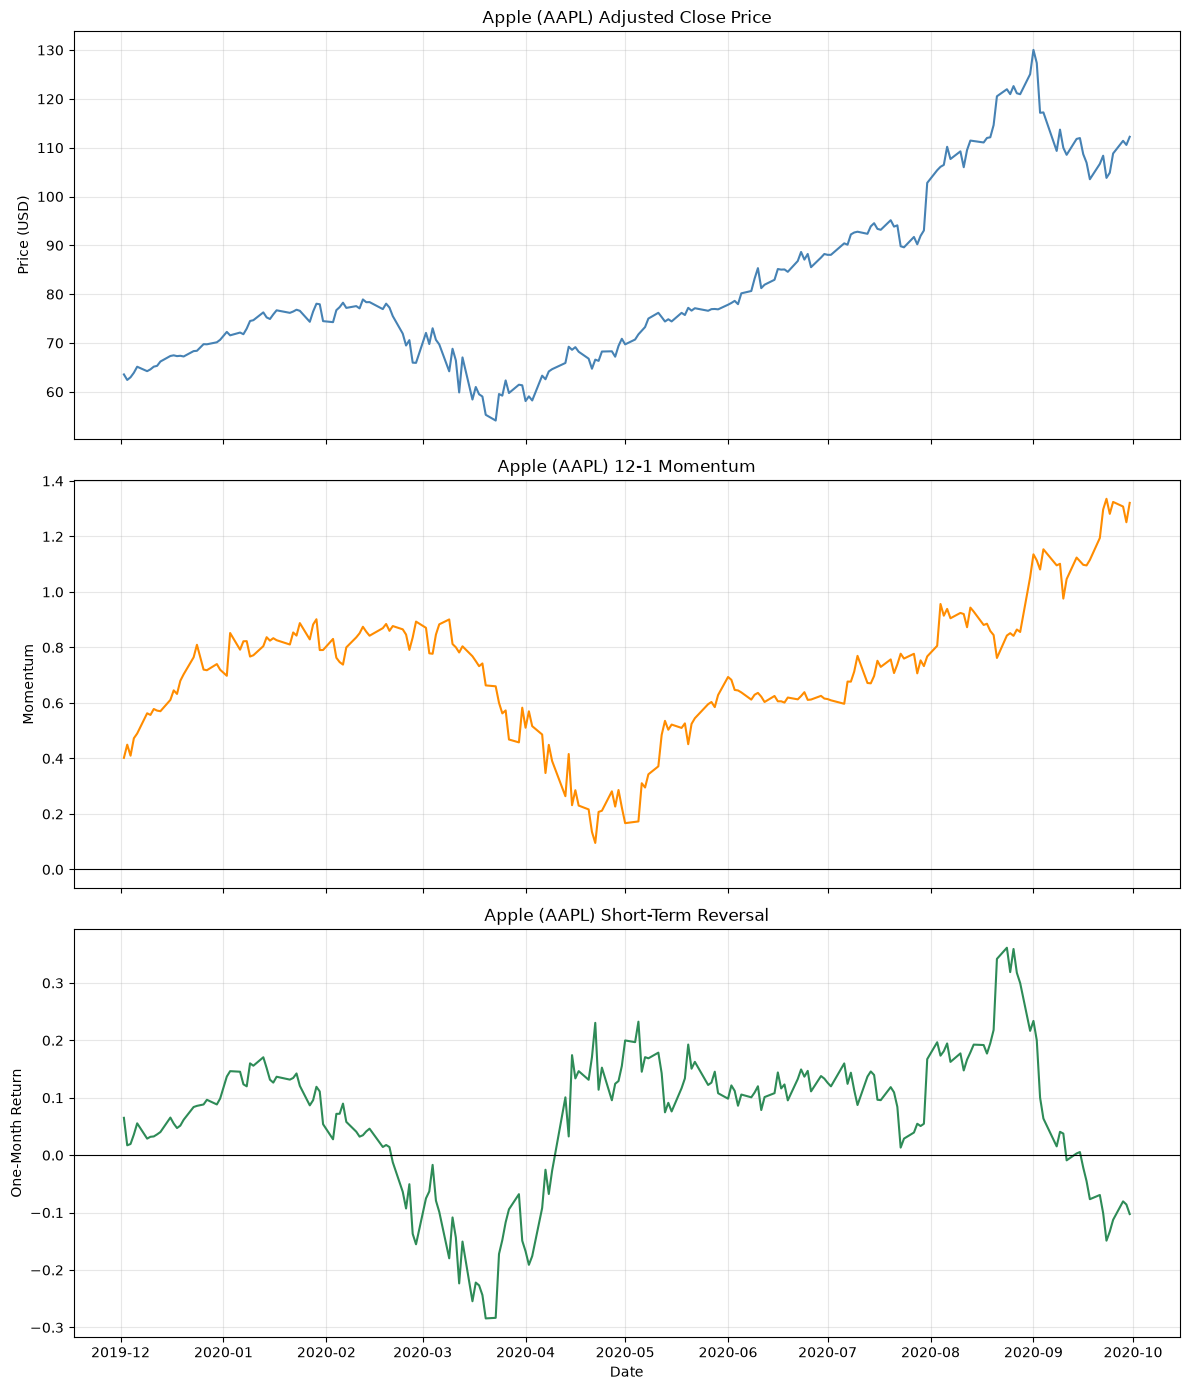

In [8]:
# Ensure that the date index has datetime format
prices.index = pd.to_datetime(prices.index)

# Calculate features using the complete price history
aapl_adj_close = prices["Adj Close"]["AAPL"]

momentum_12_1 = compute_12_1_momentum(prices)
aapl_momentum = momentum_12_1["AAPL"]

short_term_reversal = compute_short_term_reversal(prices)
aapl_reversal = short_term_reversal["AAPL"]

# Select the period to visualize
start_date = "2019-12-01"
end_date = "2020-09-30"

aapl_adj_close = aapl_adj_close.loc[start_date:end_date]
aapl_momentum = aapl_momentum.loc[start_date:end_date]
aapl_reversal = aapl_reversal.loc[start_date:end_date]

# Create three vertically stacked charts
fig, ax = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Chart 1: Adjusted Close price
ax[0].plot(aapl_adj_close.index, aapl_adj_close, color="steelblue")
ax[0].set_title("Apple (AAPL) Adjusted Close Price")
ax[0].set_ylabel("Price (USD)")
ax[0].grid(True, alpha=0.3)

# Chart 2: 12-1 momentum
ax[1].plot(aapl_momentum.index, aapl_momentum, color="darkorange")
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].set_title("Apple (AAPL) 12-1 Momentum")
ax[1].set_ylabel("Momentum")
ax[1].grid(True, alpha=0.3)

# Chart 3: Short-term reversal
ax[2].plot(aapl_reversal.index, aapl_reversal, color="seagreen")
ax[2].axhline(0, color="black", linewidth=0.8)
ax[2].set_title("Apple (AAPL) Short-Term Reversal")
ax[2].set_xlabel("Date")
ax[2].set_ylabel("One-Month Return")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The AAPL case study confirms expected signal mechanics during extreme regime shifts:

- **1-Month Lag Suppression**: The 12-1 momentum curve ignores the immediate March 2020 crash during its onset because the $t-1$ window ($21$ trading days) is purged. The drawdown reflects in the momentum signal only after month $t-1$ elapses.

- **Short-Term High-Beta Oscillations**: Short-term reversal captures immediate 21-day percentage swings without smoothing, spiking sharply during post-crash recoveries and oscillating laterally during stable upward trends.

In [10]:
# Store each Data Frame in a separate parquet file in the processed data folder
momentum_12_1.to_parquet("../data/processed/momentum_12_1.parquet")
short_term_reversal.to_parquet("../data/processed/short_term_reversal.parquet")

> **Decision**: Both factor implementations show correct temporal alignment, absence of look-ahead leakage, and distinct signal dynamics. Approved and persisted to data/processed/.

## 4. Risk, Asymmetric Volatility & Low-Volatility Factors

### 4.1 Signal Construction & Distribution Diagnostics

We compute four rolling volatility metrics over a **252-day** window to isolate total risk, asymmetric tail risk, and low-volatility anomaly premiums: rolling total volatility, downside volatility, upside volatility, and the inverse low-volatility factor ($-1 \times \text{Vol}$)

In [9]:
log_returns = pd.read_parquet("../data/processed/log_returns.parquet")

rolling_volatility = compute_rolling_volatility(log_returns, window=252)
downside_volatility = compute_downside_volatility(log_returns, window=252)
upside_volatility = compute_upside_volatility(log_returns, window=252)
low_volatility = compute_low_volatility_factor(log_returns, window=252)

In [12]:
# Dictionaries to aggregate columns side-by-side
nans_dict = {}
stats_dict = {}

# Process and extract metrics for each target factor
for name, df in [
    ("Upside Volatility", upside_volatility),
    ("Downside Volatility", downside_volatility),
    ("Low-Volatility Factor", low_volatility),
]:
    # Extract total NaNs for the top 3 tickers
    nans_dict[name] = df.isna().sum().head(3)

    # Compute global descriptive statistics across the clean panel
    stats_dict[name] = df.stack().replace([np.inf, -np.inf], np.nan).describe()

# Render horizontal summary tables
print("=== TOTAL NANS BY TICKER ===")
print(pd.DataFrame(nans_dict))
print("\n" + "=" * 80 + "\n")

print("=== GLOBAL STATISTICS ===")
print(pd.DataFrame(stats_dict))

=== TOTAL NANS BY TICKER ===
        Upside Volatility  Downside Volatility  Low-Volatility Factor
Ticker                                                               
A                      39                   46                    252
AAPL                   40                   50                    252
ABBV                  794                  798                   1006


=== GLOBAL STATISTICS ===
       Upside Volatility  Downside Volatility  Low-Volatility Factor
count       1.742790e+06         1.741089e+06           1.640689e+06
mean        1.234829e-02         1.327530e-02          -1.828961e-02
std         6.111288e-03         6.879364e-03           8.030082e-03
min         2.315583e-03         2.320789e-03          -1.137564e-01
25%         8.233276e-03         8.878296e-03          -2.154191e-02
50%         1.075395e-02         1.148147e-02          -1.627991e-02
75%         1.474741e-02         1.551793e-02          -1.283758e-02
max         9.280487e-02         9.548944

Empirical statistics confirm the presence of structural asymmetry in the S&P 500 panel. Downside volatility exhibits higher mean (**1.32**%) and median (**1.15**%) values compared to upside volatility (**1.23**% mean, **1.07**% median), reflecting the **leverage effect** during negative return days. The low-volatility factor is strictly non-positive by construction (max $-0.33\%$, min $-11.38\%$), ensuring valid sign orientation for long-short ranking algorithms.

### 4.2 Dynamic Volatility Case Study: Asymmetric Risk Regimes

We analyze Apple Inc. (AAPL) across market cycles to evaluate how total, upside, and downside risk metrics behave under different stress regimes.

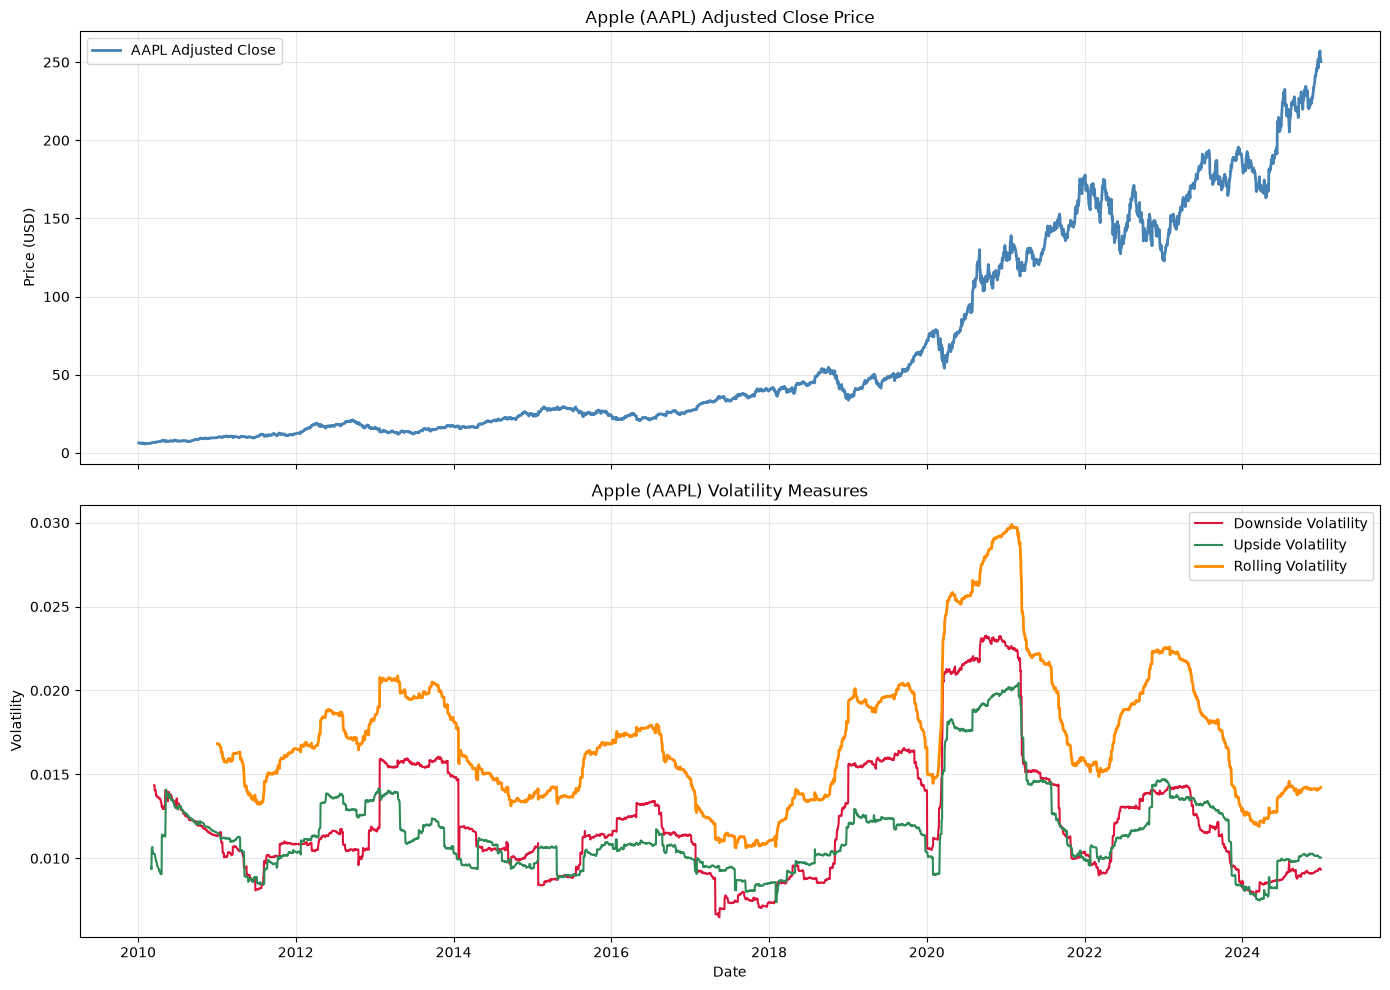

In [13]:
# Select Apple's price and volatility measures
aapl_price = prices["Adj Close"]["AAPL"]
aapl_downside_vol = downside_volatility["AAPL"]
aapl_upside_vol = upside_volatility["AAPL"]
aapl_rolling_vol = rolling_volatility["AAPL"]

# Create two vertically stacked charts
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Chart 1: Apple adjusted close price
ax[0].plot(
    aapl_price.index,
    aapl_price,
    color="steelblue",
    linewidth=2,
    label="AAPL Adjusted Close",
)
ax[0].set_title("Apple (AAPL) Adjusted Close Price")
ax[0].set_ylabel("Price (USD)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Chart 2: Apple volatility measures
ax[1].plot(
    aapl_downside_vol.index,
    aapl_downside_vol,
    color="crimson",
    label="Downside Volatility",
)
ax[1].plot(
    aapl_upside_vol.index,
    aapl_upside_vol,
    color="seagreen",
    label="Upside Volatility",
)
ax[1].plot(
    aapl_rolling_vol.index,
    aapl_rolling_vol,
    color="darkorange",
    linewidth=2,
    label="Rolling Volatility",
)

ax[1].set_title("Apple (AAPL) Volatility Measures")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Volatility")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The time-series visualization highlights key asymmetric regime properties:

- **Total Volatility Envelope**: Rolling total volatility acts as an upper envelope, absorbing combined variation across market regimes.

- **Panic Spikes (Bear Regimes)**: Downside volatility spikes aggressively during sharp market corrections (e.g., March 2020), tracking total volatility closely as forced selling accelerates.

- **Grinding Bull Regimes**: Upside volatility dominates downside volatility during steady upward trends, maintaining low overall absolute levels.

- **Short Squeezes & Rallies**: Upside volatility briefly exceeds downside volatility during aggressive buying surges (e.g., 2010 and late 2023 rallies).

### 4.3 Non-Negativity Checks & Storage

Validate non-negativity across all variance metrics before output persistence.

In [14]:
assert (
    rolling_volatility.stack().dropna() >= 0
).all(), "Error: Negative values found in rolling volatility"

assert (
    downside_volatility.stack().dropna() >= 0
).all(), "Error: Negative values found in downside volatility"

assert (
    upside_volatility.stack().dropna() >= 0
).all(), "Error: Negative values found in upside volatility"

print("All volatility checks passed: no negative values found.")

All volatility checks passed: no negative values found.


In [17]:
# Store each Data Frame in a separate parquet file in the processed data folder
rolling_volatility.to_parquet("../data/processed/rolling_volatility.parquet")
downside_volatility.to_parquet("../data/processed/downside_volatility.parquet")
upside_volatility.to_parquet("../data/processed/upside_volatility.parquet")

> Decision: All calculated risk metrics satisfy mathematical non-negativity bounds and correctly isolate asymmetric tail risk. The `rolling_volatility`, `downside_volatility`, and `upside_volatility` datasets are approved and persisted to `data/processed/`. The `low_volatility` factor is intentionally omitted from parquet storage, as it represents an exact inverse mirror ($-1 \times \text{Volatility}$) of rolling volatility and can be dynamically generated downstream to optimize storage redundancy.

## 5. Market Microstructure & Liquidity Factors

### 5.1 Amihud Illiquidity Construction & Diagnostics

We compute the 21-day rolling Amihud illiquidity metric using price and volume data. A 21-day window mitigates daily order-book noise while maintaining cross-sectional sensitivity.


In [15]:
simple_returns = pd.read_parquet("../data/processed/simple_returns.parquet")
prices = pd.read_parquet("../data/raw/sp500_prices.parquet")

amihud_illiquidity = compute_amihud_illiquidity(
    prices,
    simple_returns,
    window=21,
)

In [16]:
print("=== Amihud Illiquidity Diagnostics ===")
print(f"Total NaNs by Ticker:\n{amihud_illiquidity.isna().sum().head(3)}")
print(
    f"Global Statistics:\n{amihud_illiquidity.stack().replace([np.inf, -np.inf], np.nan).describe()}"
)

=== Amihud Illiquidity Diagnostics ===
Total NaNs by Ticker:
Ticker
A        15
AAPL     15
ABBV    769
dtype: int64
Global Statistics:
count    1.750830e+06
mean     9.218682e-10
std      5.547365e-08
min      3.571354e-13
25%      4.275270e-11
50%      8.839732e-11
75%      1.802415e-10
max      1.072517e-05
dtype: float64


The baseline metric confirms the high liquidity of the S&P 500 universe, with a median of $8.82 \times 10^{-11}$ percentage return impact per dollar traded and a strictly positive minimum ($>0$). The distribution exhibits severe **extreme right-skewness** (max = $1.07 \times 10^{-5}$, $P_{75} = \mathbf{1.80 \times 10^{-10}}$) driven by temporary volume droughts and micro-shocks.

In [23]:
amihud_illiquidity.to_parquet("../data/processed/amihud_illiquidity.parquet")

> **Decision**: The raw Amihud calculation is verified and persisted to data/processed/amihud_illiquidity.parquet. Because extreme right-skewness compresses 99% of values near zero, non-linear feature transformation (log scaling and cross-sectional Winsorization) is required in downstream preprocessing before ML model ingestion.